# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [23]:
!pip install xgboost


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [25]:
# TODO: extract the dataset zip to an output folder


# TODO: load the CSV into a DataFrame named df
df = pd.read_csv('dataset_heart.csv')

# TODO: inspect df
print(df.describe())
# TODO: identify target column
target = df['heart disease']  

# TODO: split features and target
X = df.drop(columns=['heart disease'])
y = df['heart disease'].map({1: 0, 2: 1})  # Ensure binary labels are 0 and 1

# TODO: train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
# Hint: train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)


              age        sex   chest pain type  resting blood pressure  \
count  270.000000  270.000000       270.000000              270.000000   
mean    54.433333    0.677778         3.174074              131.344444   
std      9.109067    0.468195         0.950090               17.861608   
min     29.000000    0.000000         1.000000               94.000000   
25%     48.000000    0.000000         3.000000              120.000000   
50%     55.000000    1.000000         3.000000              130.000000   
75%     61.000000    1.000000         4.000000              140.000000   
max     77.000000    1.000000         4.000000              200.000000   

       serum cholestoral  fasting blood sugar  \
count         270.000000           270.000000   
mean          249.659259             0.148148   
std            51.686237             0.355906   
min           126.000000             0.000000   
25%           213.000000             0.000000   
50%           245.000000             0.

### Basic visual checks

In [26]:
#pick a few numeric columns and plot histograms
print(df.head())
print(df['heart disease'].value_counts())

# TODO: plot class balance as a bar chart



   age  sex   chest pain type  resting blood pressure  serum cholestoral  \
0   70     1                4                     130                322   
1   67     0                3                     115                564   
2   57     1                2                     124                261   
3   64     1                4                     128                263   
4   74     0                2                     120                269   

   fasting blood sugar  resting electrocardiographic results  max heart rate  \
0                    0                                     2             109   
1                    0                                     2             160   
2                    0                                     0             141   
3                    0                                     0             105   
4                    0                                     2             121   

   exercise induced angina  oldpeak  ST segment  major vessels

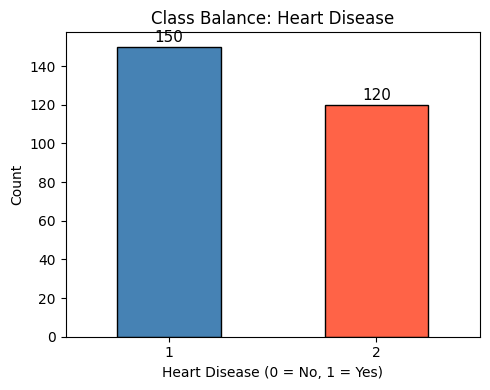

In [27]:
# --- Class balance bar chart ---
fig, ax = plt.subplots(figsize=(5, 4))
df['heart disease'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Class Balance: Heart Disease')
ax.set_xlabel('Heart Disease (0 = No, 1 = Yes)')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

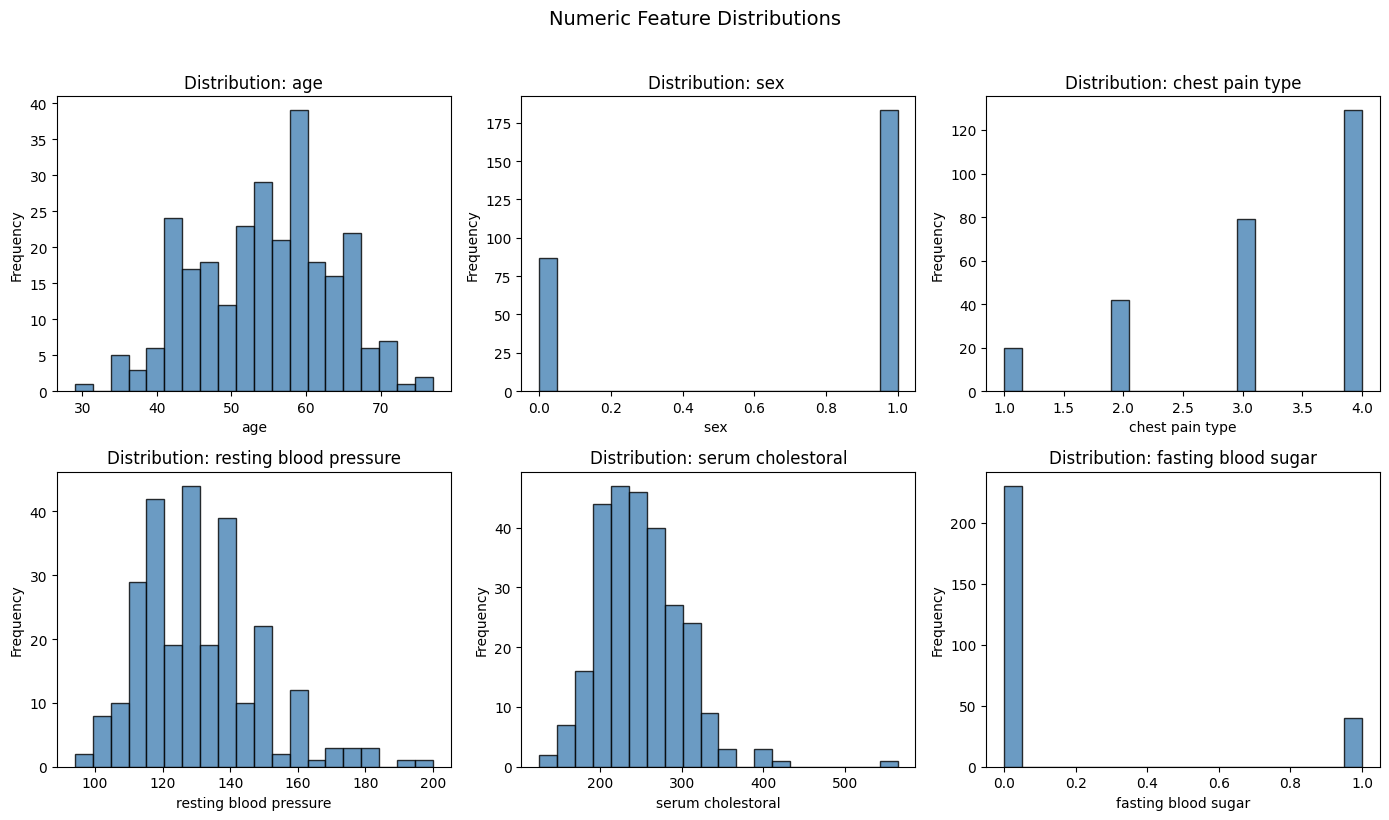

In [28]:
# Pick a few numeric columns and plot histograms
numeric_cols = df.select_dtypes(include='number').drop(columns=['heart disease']).columns.tolist()
cols_to_plot = numeric_cols[:6]  # plot up to 6 columns

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    axes[i].hist(df[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(len(cols_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Preprocessing pipeline

In [29]:
# list of object, category, or bool columns
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()  # list of object, category, or bool columns

num_cols = df.select_dtypes(include='number').drop(columns=['heart disease']).columns.tolist() # list of numeric columns

# TODO: build a ColumnTransformer named pre
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)


## Helper - evaluation function

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay


def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # TODO: predictions
    y_pred = model.predict(X_test)

    # TODO: compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }
    print(name, metrics)

    # TODO: confusion matrix plot
    # Hint: confusion_matrix(y_test, y_pred)
    # Draw with plt.imshow or ConfusionMatrixDisplay
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    # TODO: ROC curve if model has predict_proba
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        plt.plot(fpr, tpr, label=name)

    return metrics


## Exercise 2 - Logistic Regression without Grid Search

Logistic Regression (No Grid Search) {'accuracy': 0.8518518518518519, 'precision': 0.7857142857142857, 'recall': 0.9166666666666666, 'f1': 0.8461538461538461}


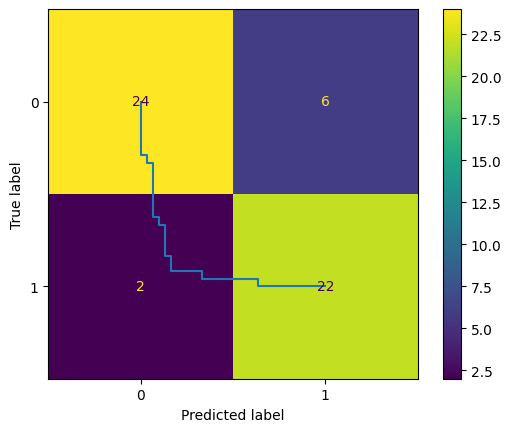

In [31]:
# TODO: create a Pipeline with your preprocessor and LogisticRegression
# Hint: solver 'liblinear' is fine, increase max_iter if needed
pipe_lr = Pipeline([
    ('pre', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: fit on training data
pipe_lr.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report("Logistic Regression (No Grid Search)", pipe_lr, X_test, y_test)


## Exercise 3 - Logistic Regression with Grid Search

Best params: {'lr__C': 0.001, 'lr__penalty': 'l2'}
LR grid {'accuracy': 0.8148148148148148, 'precision': 0.7692307692307693, 'recall': 0.8333333333333334, 'f1': 0.8}


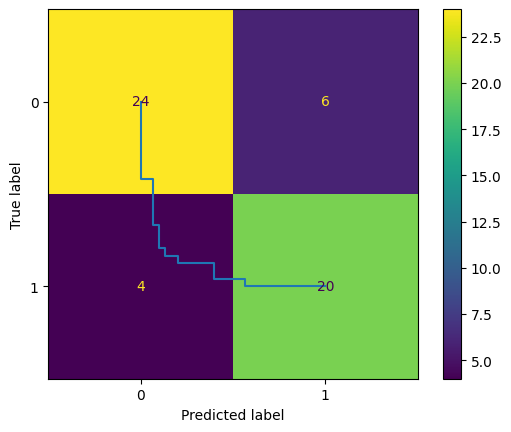

In [32]:
# TODO: build a Pipeline same as above
pipe_lr_cv = Pipeline([
    ('pre', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: define param_grid for lr__C and lr__penalty
# Hint: use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {
    'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2']
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1')
grid_lr.fit(X_train, y_train)
print('Best params:', grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)


## Exercise 4 - SVM without Grid Search

SVM no grid {'accuracy': 0.8148148148148148, 'precision': 0.7692307692307693, 'recall': 0.8333333333333334, 'f1': 0.8}


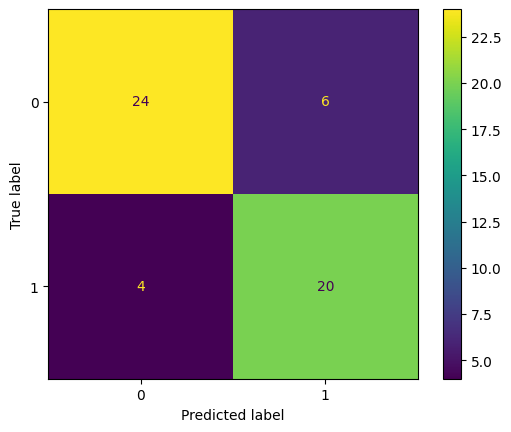

In [33]:
# TODO: choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' with C=1.0 and gamma='scale'
pipe_svm = Pipeline([
    ('pre', pre),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE))
])
pipe_svm.fit(X_train, y_train)
svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)


## Exercise 5 - SVM with Grid Search

Best params: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
SVM grid {'accuracy': 0.8518518518518519, 'precision': 0.8076923076923077, 'recall': 0.875, 'f1': 0.84}


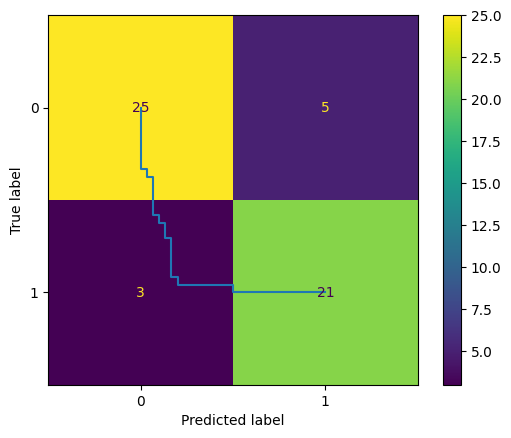

In [34]:
# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline([
    ('pre', pre),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE))
])

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'svm__kernel': ['rbf','linear'],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale','auto']
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring='f1')
grid_svm.fit(X_train, y_train)
print('Best params:', grid_svm.best_params_)
best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)


## Exercise 6 - XGBoost without Grid Search

XGB no grid {'accuracy': 0.7962962962962963, 'precision': 0.7407407407407407, 'recall': 0.8333333333333334, 'f1': 0.7843137254901961}


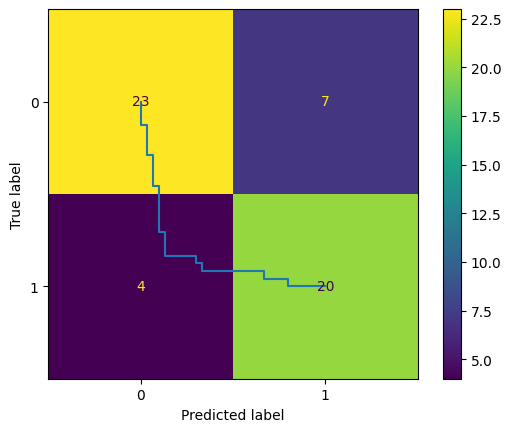

In [35]:
# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
# Hint: start with n_estimators around 300, learning_rate 0.1, max_depth 3 to 5
pipe_xgb = Pipeline([
    ('pre', pre),
    ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE))
])
pipe_xgb.fit(X_train, y_train)
xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)


## Exercise 7 - XGBoost with Grid Search

Best params: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 500, 'xgb__subsample': 1.0}
XGB grid {'accuracy': 0.8148148148148148, 'precision': 0.7692307692307693, 'recall': 0.8333333333333334, 'f1': 0.8}


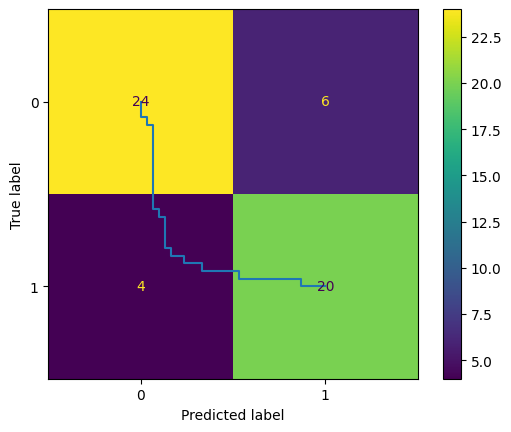

In [38]:
# TODO: Pipeline with XGBClassifier
pipe_xgb_cv = Pipeline([
    ('pre', pre),
    ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE))
])

# TODO: define a reasonable param_grid
xgb_param_grid = {
    'xgb__n_estimators': [100, 300, 500],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': [3, 5, 7],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(pipe_xgb_cv, xgb_param_grid, cv=5, scoring='f1')
grid_xgb.fit(X_train, y_train)
print('Best params:', grid_xgb.best_params_)
best_xgb = grid_xgb.best_estimator_
xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)


## Compare models

In [ ]:
summary = {
    'LR no grid':   lr_no_gs_metrics,
    'LR grid':      lr_gs_metrics,
    'SVM no grid':  svm_no_metrics,
    'SVM grid':     svm_gs_metrics,
    'XGB no grid':  xgb_no_metrics,
    'XGB grid':     xgb_gs_metrics,
}

df_summary = pd.DataFrame.from_dict(summary, orient='index')

df_summary = df_summary.sort_values('f1', ascending=False)
print(df_summary.to_string())

df_summary


             accuracy  precision    recall        f1
LR no grid   0.851852   0.785714  0.916667  0.846154
SVM grid     0.851852   0.807692  0.875000  0.840000
LR grid      0.814815   0.769231  0.833333  0.800000
SVM no grid  0.814815   0.769231  0.833333  0.800000
XGB grid     0.814815   0.769231  0.833333  0.800000
XGB no grid  0.796296   0.740741  0.833333  0.784314


,accuracy,precision,recall,f1
LR no grid,0.851852,0.785714,0.916667,0.846154
SVM grid,0.851852,0.807692,0.875000,0.840000
LR grid,0.814815,0.769231,0.833333,0.800000
SVM no grid,0.814815,0.769231,0.833333,0.800000
XGB grid,0.814815,0.769231,0.833333,0.800000
XGB no grid,0.796296,0.740741,0.833333,0.784314
